<a href="https://colab.research.google.com/github/Ahkota/INTD555-Project1-NASA-RUL/blob/main/Project1_RUL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Ahkota/INTD555-Project1-NASA-RUL

fatal: destination path 'INTD555-Project1-NASA-RUL' already exists and is not an empty directory.


**CLEANING**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# read in data,
engine_test_df = pd.read_csv("INTD555-Project1-NASA-RUL/CMaps_data/train_FD001.txt",sep=r"\s+",header=None) # read in space seperated data using r"\s+" for space without showing errors and no headers
col_names = ["engine_id","time_cycle","op_setting1","op_setting2","op_setting3"] # get header names
for i in range(1,22): # for the rest of the headers run a loop
  col_names.append(f'sensor_{i}') # loop from sensor 1 to sensor 21 and append
engine_test_df.columns = col_names # add the headers to the df

print(engine_test_df.shape) # has 20631 rows and 26 columns!

# lets only do it for first few engines not all!!
engine_test_df = engine_test_df[engine_test_df['engine_id'].isin([1,2])] # keep only engines 1-2
print(engine_test_df.shape) # has 479 rows now, better!

#need to compute RUL for each row and add it to the df
#RUL = max cycle - time_cycle
max_cycle = engine_test_df.groupby('engine_id')['time_cycle'].max().reset_index() #find the max cycle for each engine id
max_cycle.rename(columns={'time_cycle': 'max_cycle'}, inplace=True)
engine_test_df = engine_test_df.merge(max_cycle, on='engine_id', how='left') # add the max cycle column to the df

# now can get RUL for each row
engine_test_df["RUL"] = engine_test_df["max_cycle"] - engine_test_df["time_cycle"]


print(engine_test_df.dtypes) # everything is numeric, either int or float
print(engine_test_df.isnull().mean()) # mean is 0, no missing values


(20631, 26)
(479, 26)
engine_id        int64
time_cycle       int64
op_setting1    float64
op_setting2    float64
op_setting3    float64
sensor_1       float64
sensor_2       float64
sensor_3       float64
sensor_4       float64
sensor_5       float64
sensor_6       float64
sensor_7       float64
sensor_8       float64
sensor_9       float64
sensor_10      float64
sensor_11      float64
sensor_12      float64
sensor_13      float64
sensor_14      float64
sensor_15      float64
sensor_16      float64
sensor_17        int64
sensor_18        int64
sensor_19      float64
sensor_20      float64
sensor_21      float64
max_cycle        int64
RUL              int64
dtype: object
engine_id      0.0
time_cycle     0.0
op_setting1    0.0
op_setting2    0.0
op_setting3    0.0
sensor_1       0.0
sensor_2       0.0
sensor_3       0.0
sensor_4       0.0
sensor_5       0.0
sensor_6       0.0
sensor_7       0.0
sensor_8       0.0
sensor_9       0.0
sensor_10      0.0
sensor_11      0.0
sensor_12      0

2 **Exploration/Visualization**

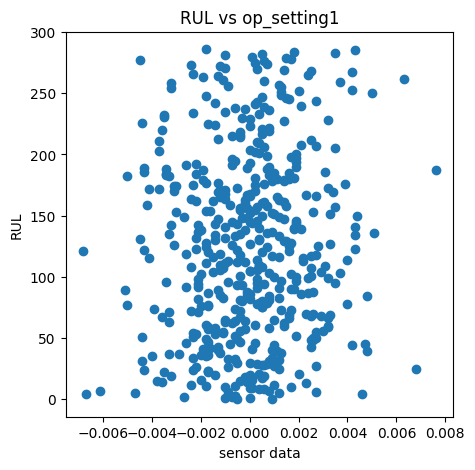

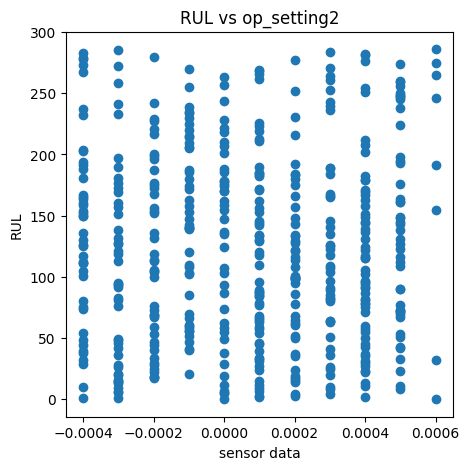

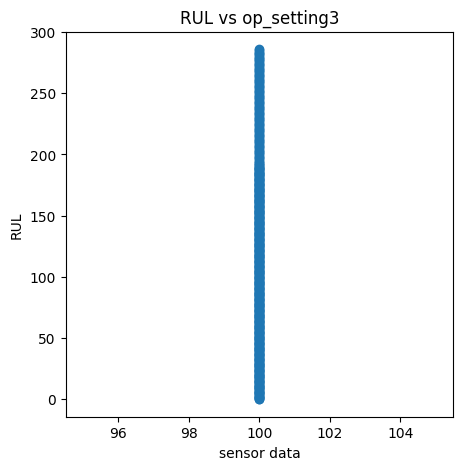

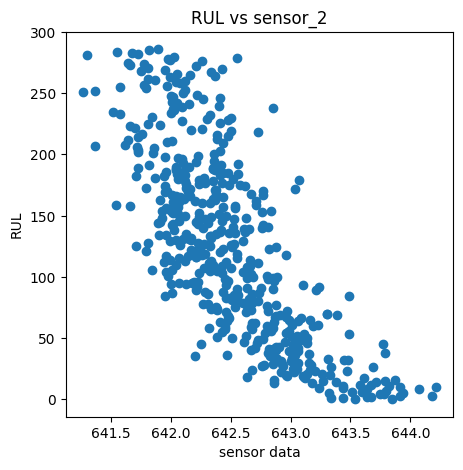

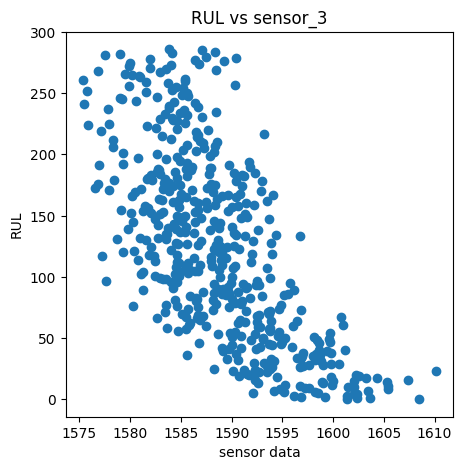

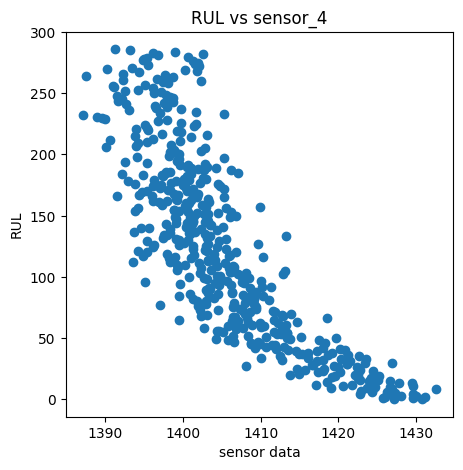

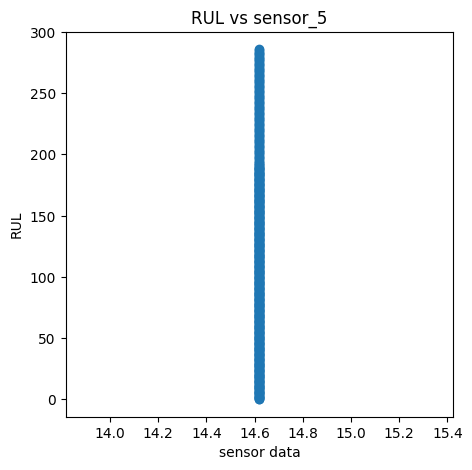

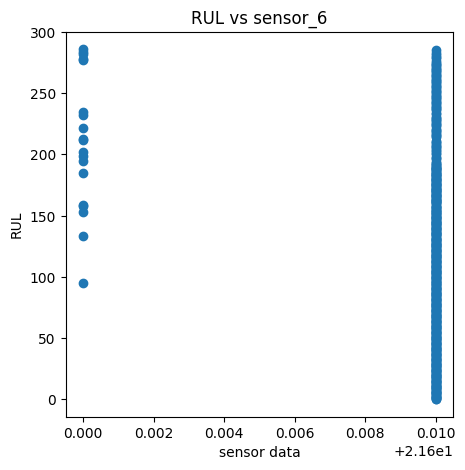

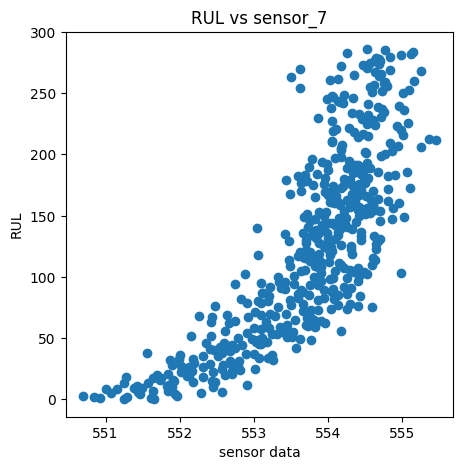

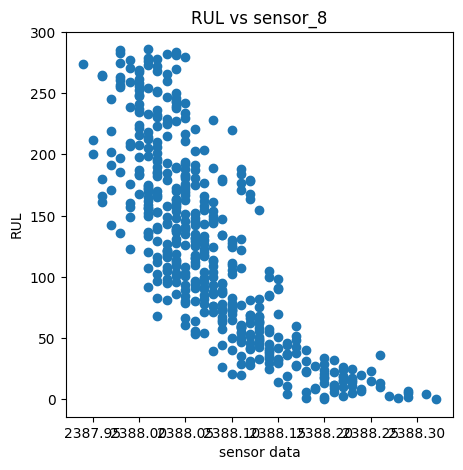

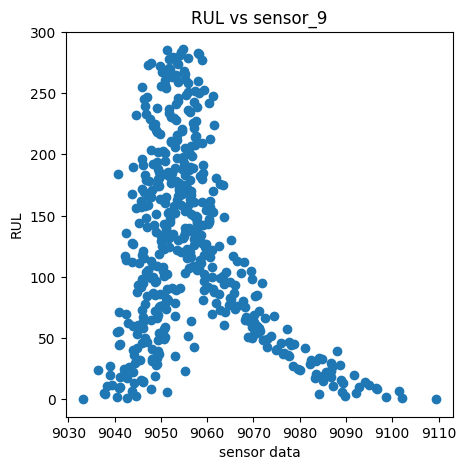

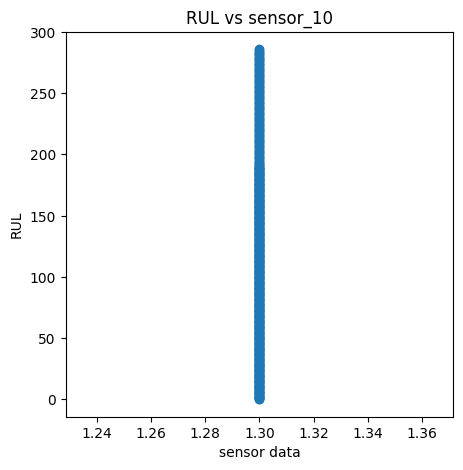

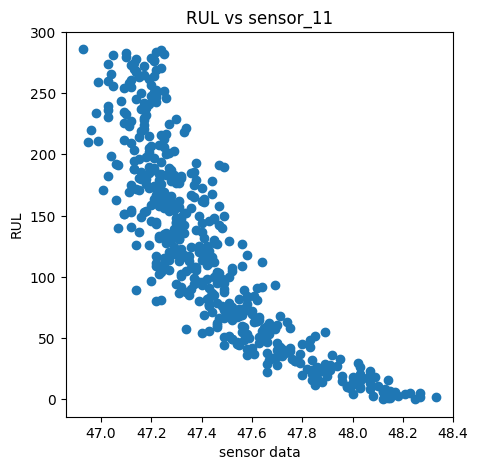

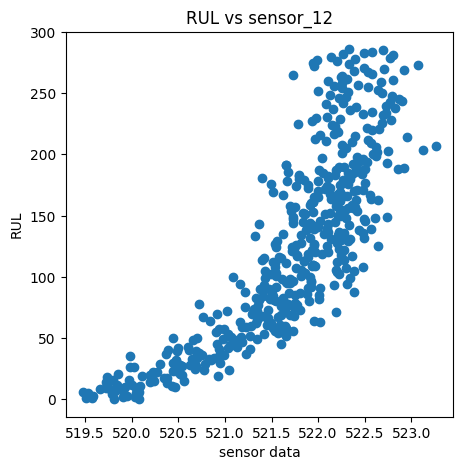

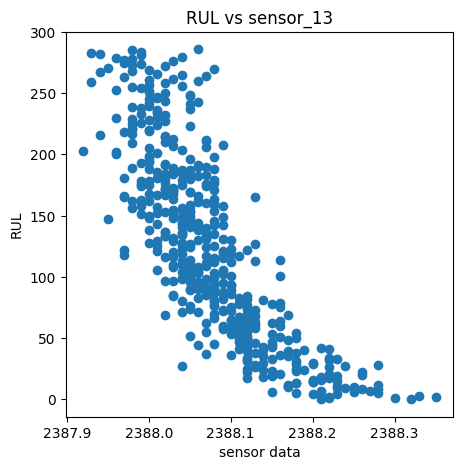

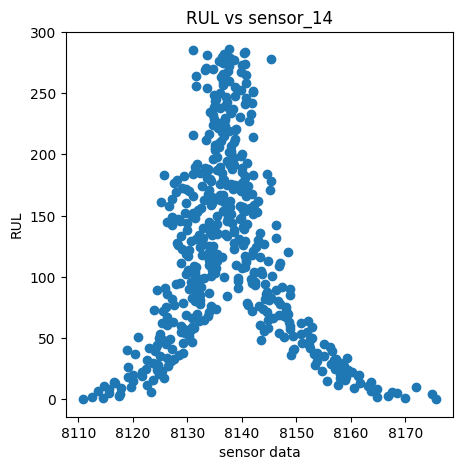

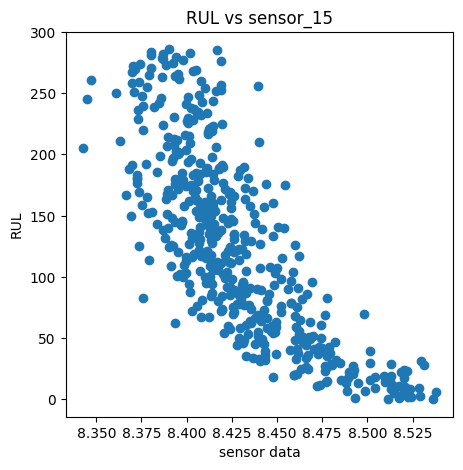

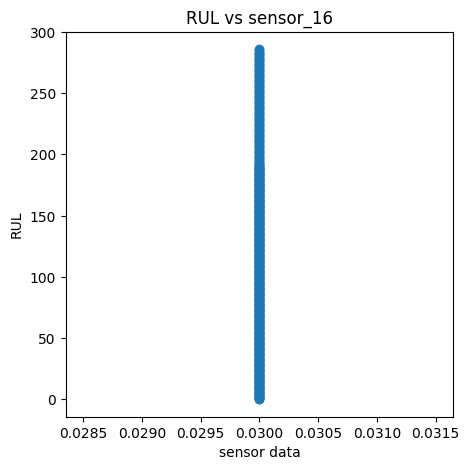

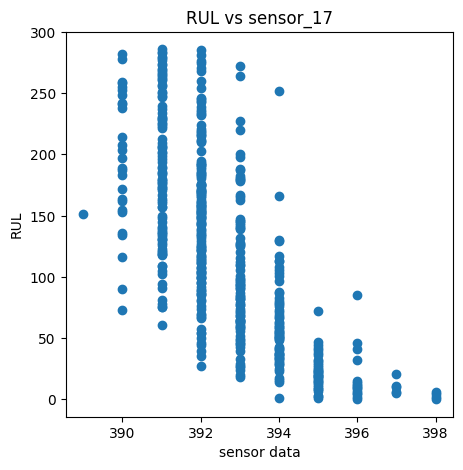

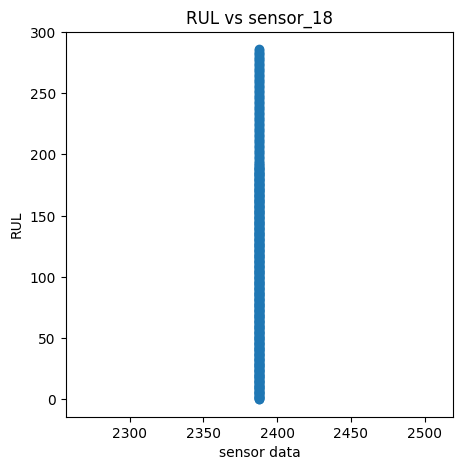

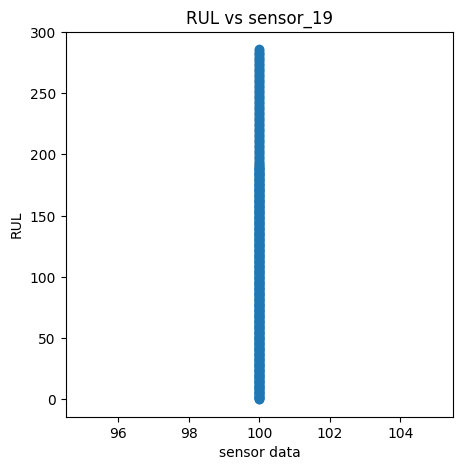

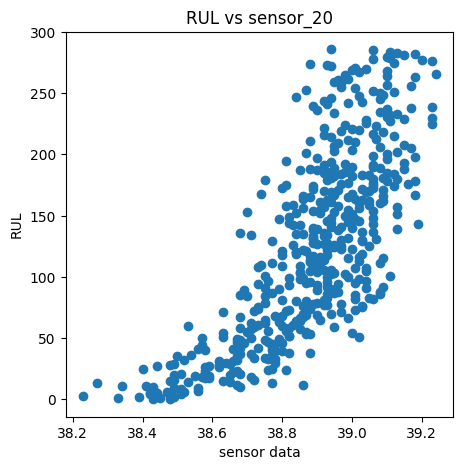

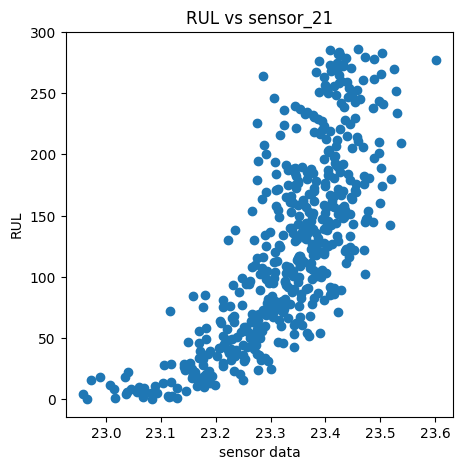

In [ ]:
# scatter plot for each op setting (1-3) to look for trends
for col in engine_test_df.columns[2:5]:
  plt.figure(figsize=(5,5))
  plt.scatter(engine_test_df[col], engine_test_df["RUL"],label=col)
  plt.title(f'RUL vs {col}' )
  plt.xlabel('sensor data')
  plt.ylabel('RUL')
  plt.show()

# scatter plot for each sensor (1-21) to look for trends
for col in engine_test_df.columns[6:-2]:
  plt.figure(figsize=(5,5))
  plt.scatter(engine_test_df[col], engine_test_df["RUL"],label=col)
  plt.title(f'RUL vs {col}' )
  plt.xlabel('sensor data')
  plt.ylabel('RUL')
  plt.show()


# from the plot can see some sensors dont change value so dont effect RUL need to remove these
sensors_remove = ["op_setting1","op_setting2","op_setting3","sensor_5","sensor_6","sensor_10","sensor_16","sensor_17","sensor_18","sensor_19","sensor_14","sensor_9"]
engine_test_df_regression = engine_test_df.drop(sensors_remove,axis=1)


The first cleaning step was to add headers to make the data meaningful, the second step is to visualize the data to understand trends and relationships between variables. This step also can be a cleaning step because some variables might just be related to setting or conditions used but not a independent variable. To visualize, scatter plots of sensor data vs remaining useful life (RUL) were created to look for relationships. Many sensors did not show a meaninful relationship (ie sensor data was constant, or did not show a clear trend and looked like a "blob" with no clear shape or relation. The other variables did show more clear trends between sensor data and RUL, sometimes a positive or negative trend with a non linear profile. Also, some sensors had more unusual trends, that are harder to model and were removed. From this a multi-non linear regression could be explored.

**3 Regression Analysis**
from the scatter plots of the other variables that did show more clear trends between sensor data and RUL, sometimes a positive or negative trend was seen. Also, the trend seemed more curved or increasing or decreasing at different points rather than consistently increasing or decreasing like a linear relationship. From this a multi non-linear regression (polynomial) could be explored

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# to do multi variable regression need x data as multiple columns, need to remove non sensor data (engine_id,max_cylces etc)
x = engine_test_df_regression.drop(columns=['engine_id', 'time_cycle', 'RUL','max_cycle'])
y = engine_test_df_regression['RUL']

# set aside some data for training and for testing model
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)  #20 percent test

poly = PolynomialFeatures(degree=2, include_bias=False) # polynomail with degree 2
x_train_poly = poly.fit_transform(x_train) #fit to the trained data
x_test_poly = poly.transform(x_test) # apply to test data

# Train the Model
model = LinearRegression() # using linear regression but with a polynomial transformation
model.fit(x_train_poly, y_train)

# Make predictions and evaluate
predictions = model.predict(x_test_poly)
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error (MAE): {int(mae):} cycles")
print(f"Root Mean Squared Error (RMSE): {int(rmse):} cycles")
print(f"R squared {float(r2):}")



Mean Absolute Error (MAE): 21 cycles
Root Mean Squared Error (RMSE): 27 cycles
R squared 0.8797785894629868


Text(0, 0.5, 'Residual Error (Actual - Predicted)')

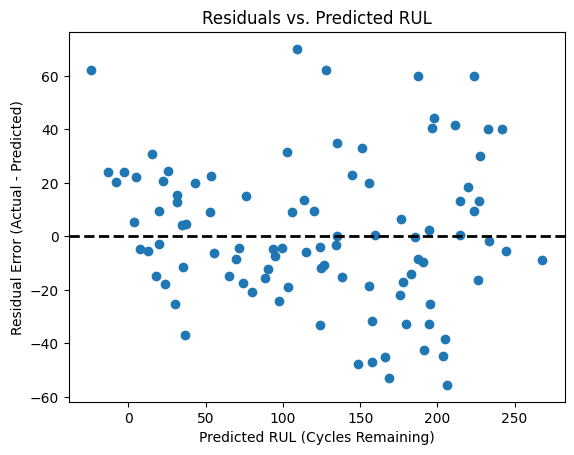

In [ ]:
# Calculate the residuals (errors)
residuals = y_test - predictions

plt.scatter(x=predictions, y=residuals)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.title('Residuals vs. Predicted RUL')
plt.xlabel('Predicted RUL (Cycles Remaining)')
plt.ylabel('Residual Error (Actual - Predicted)')



Summative Report - Communication stage

The multiple polynomial regression model predicts engne failure by looking at the target variabl, remaining useful life (RUL) or cycles of jet engines and trends in sensor data. Based on the R squared value of 0.88, indicating a strong model fit. The MAE is 21 cycles and RMSE is 27 cycles, lower values of MAE and RMSE is better. They are also close to each other meaning the smaller the varaince in errors. From the analysis it can be concluded that engine failure can be accaturely predicted allowing engineers or maintence people to repair or replace the engine before castophic failture